# Projeto 1 · Parte 1 — Preparando os dados

Você vai treinar um detector de pessoas em imagens térmicas capturadas por drone e, ao final,
responder a uma pergunta operacional: **este modelo serve para uma missão de busca e salvamento?**

A resposta não é um número de acurácia. Em busca e salvamento, deixar de encontrar uma pessoa
(um falso negativo) e disparar um alarme falso não têm o mesmo custo. Um detector com 90% de
recall pode ser inútil se os 10% de pessoas que ele perde forem justamente as pessoas parcialmente
ocultas pela vegetação — que são o caso difícil e, não por acaso, o caso real.

Este é o **primeiro de dois notebooks**:

| Notebook | O que faz | Precisa de GPU? | Tempo |
|---|---|---|---|
| **01 · Preparando os dados** (você está aqui) | baixa o POP, verifica integridade, converte formato e audita os splits | não | ~10 min |
| **02 · Experimento completo** | treina, avalia e mede o desempenho final | **sim** | estimativa de 1h10–1h30 com parada antecipada; até ~3 h |

Execute este notebook primeiro. Ele não exige GPU — você pode rodá-lo em qualquer máquina
para inspecionar os dados antes de gastar tempo de placa.

## Pré-requisitos

- Cerca de **10 GB livres** em disco.
- Python **3.10 a 3.12**, em ambiente próprio do Projeto 1 (veja [README](README.md)).

Se você não tem GPU para a parte 2, o README deste projeto explica como alugar uma por hora.

## O dataset

Usaremos o **POP** (*Partially Occluded Person*), publicado por Song et al. (2025) no
*Scientific Data*. São 8.768 imagens térmicas aéreas de pessoas em ambientes naturais,
capturadas a 30, 50 e 70 metros de altitude, com 26.811 pessoas anotadas — muitas delas
parcialmente ocultas por vegetação.

> Song, Y. et al. *An infrared dataset for partially occluded person detection in complex
> environment for search and rescue.* Scientific Data 12, 2025.
> https://doi.org/10.1038/s41597-025-04600-0

## 1. Configuração do experimento

Todos os parâmetros do experimento ficam nesta única célula. Essa concentração é deliberada:
quando os parâmetros estão espalhados pelo notebook, é impossível saber, ao ler um resultado,
qual configuração o produziu.

Os parâmetros distinguem os valores reportados no artigo das adaptações desta atividade.

**Orçamento de treinamento e adaptação didática.** Song et al. reportam treinamento por
100 épocas, com batch 16 e `lr0=1e-3`. Na preparação deste material, também realizamos uma
execução completa de 100 épocas. Para reduzir o tempo e o custo da atividade, esta versão
mantém `EPOCAS=100` como limite e adota `PACIENCIA=10`: o treinamento pode terminar após
10 épocas consecutivas sem melhora no critério de validação da Ultralytics.

Esta parada antecipada é uma decisão didática nossa, não uma configuração atribuída ao artigo.
A quantidade efetiva de épocas será registrada no notebook 02. Não há garantia de encerrar
em uma época específica nem de obter o mesmo resultado da execução anterior. A análise final
deve explicitar essa diferença metodológica ao comparar os resultados com o artigo.

**Por que `imgsz=1280`?** As imagens do POP são 1280×1024 e as pessoas aparecem pequenas: a
mediana do menor lado de uma pessoa anotada fica em torno de 34 pixels, e 10% delas têm 20
pixels ou menos. Treinar a 640 px cortaria esses valores pela metade, levando a mediana a 17
pixels — e destruiria justamente o sinal que precisamos detectar. Os números estão na seção 6.

O parâmetro `SEMENTE` fixa a aleatoriedade (inicialização, ordem dos lotes, sorteios da
augmentation) para que sua execução seja reproduzível. Os autores não informam qual semente
usaram, então a nossa é uma decisão desta reprodução, não uma escolha deles.

In [1]:
# ===== Parâmetros do experimento =====

# Valores de referência reportados por Song et al. (2025)
EPOCAS = 100              # limite máximo; a versão didática pode encerrar antes
BATCH = 16
LR0 = 1e-3
OTIMIZADOR = "SGD"
IMGSZ = 1280
CONF_PAPER = 0.50          # limiar de confiança usado pelos autores ao reportar as métricas

# Decisões desta reprodução (não reportadas no artigo)
MODELO_BASE = "yolov8s.pt"  # pesos pré-treinados no COCO
SEMENTE = 0
PACIENCIA = 10            # adaptação didática: épocas sem melhora na validação

# Requisito da missão de busca e salvamento — definido por nós, não pelo artigo
IOU_MATCH = 0.50            # sobreposição mínima para considerar que uma detecção achou a pessoa
RECALL_ALVO = 0.90          # queremos encontrar 90% das pessoas...
FPPI_MAX = 1.0              # ...sem passar de 1 alarme falso por imagem, em média

NOME_EXECUCAO = f"yolov8s-pop-seed{SEMENTE}-es{PACIENCIA}"
print("Execução:", NOME_EXECUCAO)

Execução: yolov8s-pop-seed0-es10


## 2. Ambiente

Fixamos a versão exata da biblioteca, e aqui há uma razão a mais: **a 8.2.0 é a própria versão
citada pelos autores** (referência 35 do artigo). Reproduzir um experimento com outra versão do
mesmo software introduz uma variável que você não controla nem consegue medir.

Isso não é preciosismo: entre versões da Ultralytics mudam defaults de augmentation, de perda e
de pós-processamento. Se você rodar este notebook
com outra versão e obtiver números diferentes, não saberá se a diferença veio do seu hardware,
da sua semente ou de uma mudança de default que ninguém anunciou.

Prepare o ambiente no terminal com `uv sync --locked` e abra `uv run --locked jupyter lab`
na pasta `projeto-1`. Selecione o kernel **POP (torch 2.5.1)**. Não é necessário instalar pacotes
dentro do notebook. Se acabou de trocar versões, **reinicie o kernel** antes de continuar.

A célula seguinte também registra hardware, CUDA e versões em um arquivo `ambiente_preparacao.json`.
Guarde esse arquivo junto com seus resultados — sem ele, um número de mAP é apenas um número.

> **Atenção à versão do PyTorch.** A Ultralytics 8.2.0 carrega checkpoints de um modo que deixou
> de funcionar no PyTorch 2.6, quando o argumento `weights_only` do `torch.load` mudou de padrão.
> Se você usar PyTorch 2.6 ou superior, o carregamento do `yolov8s.pt` falhará. Use **torch 2.5.1 com torchvision 0.20.1**. Essa é uma restrição de compatibilidade entre bibliotecas, necessária
> para executar esta reprodução.

In [2]:
# O ambiente é preparado no terminal, na pasta projeto-1: uv sync --locked
# Abra o Jupyter com: uv run --locked jupyter lab
import sys

if not (3, 10) <= sys.version_info[:2] < (3, 13):
    raise RuntimeError("Use o ambiente uv do projeto, com Python 3.12 por padrão.")
print("Python do kernel:", sys.executable)
print("Selecione o kernel POP (torch 2.5.1); a próxima célula verifica as bibliotecas.")


Python do kernel: /opt/pop-es10-env/bin/python3
Selecione o kernel POP (torch 2.5.1); a próxima célula verifica as bibliotecas.


In [3]:
import hashlib, json, math, os, platform, random, shutil, tempfile, urllib.request, zipfile
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision

os.environ.setdefault("YOLO_CONFIG_DIR", str(Path(tempfile.gettempdir()) / "Ultralytics"))
import ultralytics
from ultralytics import YOLO

plt.rcParams["font.family"] = "DejaVu Sans"

# As versões são requisito, não recomendação: a ultralytics 8.2.0 carrega checkpoints com
# torch.load() sem weights_only=False, e o padrão desse argumento mudou no torch 2.6.
# Verificamos aqui, na máquina barata, para não descobrir o problema com a GPU já alugada.
assert ultralytics.__version__ == "8.2.0", (
    f"ultralytics {ultralytics.__version__} instalada; este projeto exige a 8.2.0 (veja o README)"
)
assert torch.__version__.split("+")[0] == "2.5.1", (
    f"torch {torch.__version__} instalado; use torch 2.5.1 e reinicie o kernel (veja o README)."
)
assert torchvision.__version__.split("+")[0] == "0.20.1", "Use torchvision 0.20.1."
assert np.__version__ == "1.26.4", "Use numpy 1.26.4 e reinicie o kernel."
YOLO(MODELO_BASE)  # se o ambiente estiver errado, a falha acontece aqui — sem custo de GPU
print("Ambiente verificado: um checkpoint YOLO carrega corretamente.")

# Este notebook não exige GPU. Se você estiver sem placa, está tudo certo.
print("GPU disponível:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "não (esperado nesta etapa)")

# Escolhe a raiz de trabalho conforme o ambiente (RunPod, Colab ou máquina local)
if os.environ.get("POP_RAIZ"):
    RAIZ = Path(os.environ["POP_RAIZ"]).expanduser().resolve()
elif Path("/workspace").exists():
    RAIZ = Path("/workspace/projeto-pop")
elif Path("/content").exists():
    RAIZ = Path("/content/projeto-pop")
else:
    RAIZ = Path.cwd() / "projeto-pop"

DADOS = RAIZ / "data"
EXEC = RAIZ / "runs" / NOME_EXECUCAO
for p in (DADOS, EXEC):
    p.mkdir(parents=True, exist_ok=True)

# Em servidores alugados, /workspace costuma ser o ponto de montagem do volume persistente —
# mas o diretório também existe no disco temporário do contêiner quando nenhum volume foi
# anexado. Nesse caso tudo funciona normalmente e você perde os dados ao desligar a máquina.
if str(RAIZ).startswith("/workspace") and not os.path.ismount("/workspace"):
    print("AVISO: /workspace não parece ser um volume persistente montado.")
    print("       Confirme no painel o tipo de armazenamento antes de encerrar a máquina.")
    print("       Se você alugou um servidor, verifique se o volume foi anexado em /workspace.")

random.seed(SEMENTE)
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMENTE)


def agora():
    return datetime.now(timezone.utc).isoformat()


def sha256(caminho, bloco=8 * 1024 * 1024):
    h = hashlib.sha256()
    with open(caminho, "rb") as f:
        for parte in iter(lambda: f.read(bloco), b""):
            h.update(parte)
    return h.hexdigest()


ambiente = {
    "registrado_em": agora(),
    "python": platform.python_version(),
    "numpy": np.__version__,
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "ultralytics": ultralytics.__version__,
    "semente": SEMENTE,
}
(RAIZ / "ambiente_preparacao.json").write_text(json.dumps(ambiente, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(ambiente, indent=2, ensure_ascii=False))
print("\nDiretório do experimento:", EXEC)

/opt/pop-es10-env/lib/python3.12/site-packages/ultralytics/nn/tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")


Ambiente verificado: um checkpoint YOLO carrega corretamente.
GPU disponível: NVIDIA GeForce RTX 4090
{
  "registrado_em": "2026-09-19T13:14:12.121486+00:00",
  "python": "3.12.3",
  "numpy": "1.26.4",
  "torch": "2.5.1+cu121",
  "cuda": "12.1",
  "gpu": "NVIDIA GeForce RTX 4090",
  "ultralytics": "8.2.0",
  "semente": 0
}

Diretório do experimento: /workspace/projeto-pop-es10-20260919/runs/yolov8s-pop-seed0-es10


## 3. Os dados: baixar e verificar

Antes de treinar qualquer coisa, é preciso ter certeza de que os dados são os que você pensa
que são. A célula abaixo baixa o POP e confere o **SHA-256** do arquivo — uma impressão digital
criptográfica do conteúdo.

Isso parece excesso de zelo, mas resolve um problema real: downloads truncam, espelhos servem
versões antigas, e um dataset silenciosamente diferente produz resultados que você não consegue
explicar nem reproduzir. Verificar o hash custa segundos e elimina essa classe inteira de dúvida.

A extração também é feita com cuidado: verificamos que nenhum caminho dentro do ZIP aponta para
fora do diretório de destino. Um arquivo `.zip` malicioso pode conter caminhos como `../../etc/`,
e extrair sem checar sobrescreveria arquivos do sistema. O dataset do POP é confiável; o hábito
de verificar é que importa.

O download tem aproximadamente 613 MiB e leva alguns minutos.

In [4]:
POP_URL = "https://osf.io/download/gm8u2/"
POP_SHA = "14e7c4ddffe6555de1da9033217a7d95981fa1bc63f9cd6a514c348e593741cf"

# Valores esperados: (número de imagens, número de pessoas anotadas) por split
ESPERADO = {
    "train": (5548, 18425),
    "val":   (2320, 6546),
    "test":  (900, 1840),
}
LARGURA, ALTURA = 1280, 1024
POP_YOLO = DADOS / "pop_yolo"
YAML = POP_YOLO / "pop.yaml"

# Reutiliza os arquivos originais obtidos na análise exploratória (notebook 00).
raiz_projeto = Path.cwd()
if not (raiz_projeto / "01_preparacao_dados.ipynb").is_file():
    raiz_projeto = raiz_projeto / "projeto-1"
dados_eda = raiz_projeto / "dados"
arquivo_zip = dados_eda / "POP.zip" if (dados_eda / "POP.zip").is_file() else DADOS / "POP.zip"
if not arquivo_zip.exists():
    parcial = DADOS / "POP.zip.part"
    print("Baixando o POP (~613 MiB)...")
    urllib.request.urlretrieve(POP_URL, parcial)
    if sha256(parcial) != POP_SHA:
        raise ValueError("SHA-256 inesperado: o download não corresponde ao arquivo auditado.")
    parcial.replace(arquivo_zip)

assert sha256(arquivo_zip) == POP_SHA, "O POP.zip local não confere com o hash esperado."
print("POP.zip íntegro:", POP_SHA)


def extrair_zip_seguro(arquivo, destino):
    '''Extrai um ZIP recusando caminhos que escapem do diretório de destino.'''
    destino = Path(destino)
    base = destino.resolve()
    with zipfile.ZipFile(arquivo) as z:
        for info in z.infolist():
            alvo = (destino / info.filename).resolve()
            if os.path.commonpath([str(base), str(alvo)]) != str(base):
                raise ValueError(f"Caminho inseguro dentro do ZIP: {info.filename}")
        z.extractall(destino)


dados_eda_completos = all((dados_eda / "POP" / s / "Annotations" / f"{s}.json").is_file()
                         for s in ("train", "val", "test"))
extraido = dados_eda if dados_eda_completos else DADOS / "original"
if not dados_eda_completos and not (extraido / ".completo").exists():
    print("Extraindo...")
    extrair_zip_seguro(arquivo_zip, extraido)
    (extraido / ".completo").write_text(agora(), encoding="utf-8")

raizes = [p.parent.parent.parent for p in extraido.rglob("train/Annotations/train.json")]
assert len(raizes) == 1, f"Estrutura inesperada dentro do ZIP: {raizes}"
ORIGEM = raizes[0]
print("Raiz do dataset:", ORIGEM)

POP.zip íntegro: 14e7c4ddffe6555de1da9033217a7d95981fa1bc63f9cd6a514c348e593741cf
Raiz do dataset: /workspace/projeto-1-es10-20260919/repo/projeto-1/dados/POP


## 4. Conversão para o formato YOLO

O POP é distribuído em formato COCO: um arquivo JSON por split, com as caixas descritas como
`[x, y, largura, altura]` em pixels, a partir do canto superior esquerdo. A Ultralytics espera
um arquivo `.txt` por imagem, com as caixas descritas como `[centro_x, centro_y, largura, altura]`
normalizadas entre 0 e 1.

A conversão é aritmética simples, mas é exatamente o tipo de código onde erros silenciosos se
instalam: uma caixa convertida errado não gera exceção — gera um modelo pior, sem explicação.
Por isso a função `linha_yolo` **valida antes de converter**: rejeita coordenadas não finitas,
larguras não positivas e caixas que ultrapassem os limites da imagem.

Ao final, conferimos que o número de caixas escritas é exatamente o número de anotações lidas.
Se a conversão perdesse uma caixa em algum caminho, essa verificação acusaria.

Usamos *hard links* em vez de copiar as imagens: o mesmo arquivo passa a ser referenciado por
dois caminhos, sem ocupar espaço em disco duas vezes.

In [5]:
def linha_yolo(anotacao, largura, altura):
    '''Converte uma anotação COCO em uma linha no formato YOLO, validando a caixa.'''
    x, y, w, h = map(float, anotacao["bbox"])
    if anotacao["category_id"] != 1:
        raise ValueError(f"Categoria inesperada: {anotacao['category_id']}")
    if not all(math.isfinite(v) for v in (x, y, w, h)):
        raise ValueError("Bounding box com coordenada não finita")
    if w <= 0 or h <= 0 or x < 0 or y < 0 or x + w > largura + 1e-5 or y + h > altura + 1e-5:
        raise ValueError(f"Bounding box fora dos limites da imagem: {anotacao['bbox']}")
    xc, yc = (x + w / 2) / largura, (y + h / 2) / altura
    return f"0 {xc:.8f} {yc:.8f} {w/largura:.8f} {h/altura:.8f}"


contagens = {}
for split, (n_img_esperado, n_box_esperado) in ESPERADO.items():
    coco = json.loads((ORIGEM / split / "Annotations" / f"{split}.json").read_text(encoding="utf-8"))
    assert [(c["id"], c["name"]) for c in coco["categories"]] == [(1, "person")]
    assert (len(coco["images"]), len(coco["annotations"])) == (n_img_esperado, n_box_esperado), \
        f"Contagem inesperada em {split} — o dataset não é o esperado."

    por_imagem = defaultdict(list)
    for a in coco["annotations"]:
        por_imagem[a["image_id"]].append(a)

    dir_img = POP_YOLO / "images" / split
    dir_lbl = POP_YOLO / "labels" / split
    dir_img.mkdir(parents=True, exist_ok=True)
    dir_lbl.mkdir(parents=True, exist_ok=True)

    n_boxes = 0
    for im in coco["images"]:
        assert (im["width"], im["height"]) == (LARGURA, ALTURA)
        origem = ORIGEM / split / "JPEGImages" / im["file_name"]
        destino = dir_img / im["file_name"]
        assert origem.is_file()
        if not destino.exists():
            try:
                os.link(origem, destino)       # hard link: não duplica o arquivo em disco
            except OSError:
                shutil.copy2(origem, destino)  # se o sistema de arquivos não permitir, copia

        linhas = [linha_yolo(a, LARGURA, ALTURA) for a in por_imagem[im["id"]]]
        (dir_lbl / f"{Path(im['file_name']).stem}.txt").write_text("\n".join(linhas) + "\n", encoding="utf-8")
        n_boxes += len(linhas)

    assert n_boxes == n_box_esperado, f"Perdemos caixas na conversão de {split}."
    contagens[split] = {"imagens": n_img_esperado, "pessoas": n_boxes}

YAML.write_text(
    f"path: {json.dumps(str(POP_YOLO), ensure_ascii=False)}\n"
    "train: images/train\n"
    "val: images/val\n"
    "test: images/test\n"
    "names:\n"
    "  0: person\n",
    encoding="utf-8",
)

df_contagens = pd.DataFrame(contagens).T
display(df_contagens)
print("Total de imagens:", int(df_contagens.imagens.sum()))
print("Total de pessoas anotadas:", int(df_contagens.pessoas.sum()))

,imagens,pessoas
train,5548,18425
val,2320,6546
test,900,1840


Total de imagens: 8768
Total de pessoas anotadas: 26811


## 5. Os splits e o vazamento que quase ninguém vê

O POP é distribuído já dividido em treino, validação e teste — e essa divisão é **por cena**,
não por imagem. Vamos entender por que isso importa.

As imagens do POP vêm de voos: o drone sobrevoa a área a cerca de 1 m/s e a câmera térmica
registra **uma imagem por segundo** (Song et al., Métodos). Dois quadros consecutivos estão,
portanto, separados por poucos metros: cobrem quase a mesma vegetação, a mesma pessoa em quase
a mesma posição, sob a mesma temperatura.

Imagine que dividíssemos as imagens aleatoriamente. O quadro nº 100 cairia no treino e o nº 101
no teste. O modelo teria efetivamente *visto* a imagem de teste durante o treinamento. O resultado
seria um desempenho excelente no papel e decepcionante em campo — porque a métrica estaria medindo
memorização, não capacidade de generalizar para uma área nova.

A divisão oficial separa **identificadores de cena inteiros**. Isso reduz o compartilhamento
de imagens de uma mesma sequência, mas não comprova independência geográfica: a Tabela 4
atribui as mesmas coordenadas a F6 (treino) e T1 (teste), em datas distintas. O notebook 00
explicita essa limitação.

A célula abaixo constrói um catálogo de todas as imagens e **verifica** que nenhuma cena aparece
em dois splits. Não confie que o dataset está correto — verifique.

Repare também na coluna `imagens_sem_pessoa`. O valor é zero nos três splits: **toda** imagem do
POP contém pelo menos uma pessoa. Isso terá consequência na hora de medir alarmes falsos, e
voltaremos ao ponto nas limitações do notebook 02.

In [6]:
def ler_rotulos_yolo(caminho_txt, largura, altura):
    """Lê caixas YOLO sem tratar um rótulo ausente ou inválido como imagem vazia."""
    caixas = []
    for numero, linha in enumerate(Path(caminho_txt).read_text(encoding="utf-8").splitlines(), 1):
        if not linha.strip():
            continue
        partes = linha.split()
        if len(partes) != 5:
            raise ValueError(f"Rótulo inválido em {caminho_txt}, linha {numero}")
        classe, xc, yc, w, h = map(float, partes)
        if (not all(math.isfinite(v) for v in (classe, xc, yc, w, h))
                or classe != 0 or w <= 0 or h <= 0
                or xc - w/2 < -1e-7 or yc - h/2 < -1e-7
                or xc + w/2 > 1 + 1e-7 or yc + h/2 > 1 + 1e-7):
            raise ValueError(f"Caixa inválida em {caminho_txt}, linha {numero}")
        caixas.append([(xc - w/2) * largura, (yc - h/2) * altura,
                       (xc + w/2) * largura, (yc + h/2) * altura])
    return np.asarray(caixas, dtype=np.float64).reshape(-1, 4)


def cena_indice_altitude(stem):
    '''Os nomes de arquivo do POP codificam cena, índice do quadro e altitude do voo.'''
    partes = stem.split("_")
    try:
        altitude = float(partes[2])
    except (IndexError, ValueError):
        altitude = float("nan")
    return partes[0], int(partes[1]), altitude


def faixa_altitude(altitude):
    return min((30, 50, 70), key=lambda a: abs(a - altitude)) if altitude == altitude else None


linhas, lados_por_split = [], defaultdict(list)
for split in ("train", "val", "test"):
    for img in sorted((POP_YOLO / "images" / split).iterdir()):
        if img.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        cena, indice, altitude = cena_indice_altitude(img.stem)
        caixas = ler_rotulos_yolo(POP_YOLO / "labels" / split / f"{img.stem}.txt", LARGURA, ALTURA)
        if len(caixas):
            lados = np.minimum(caixas[:, 2] - caixas[:, 0], caixas[:, 3] - caixas[:, 1])
            lados_por_split[split].extend(lados.tolist())
        linhas.append({
            "split": split, "caminho": str(img), "stem": img.stem,
            "cena": cena, "indice": indice, "altitude": altitude,
            "faixa": faixa_altitude(altitude), "pessoas": len(caixas),
        })

catalogo = pd.DataFrame(linhas)
resumo = catalogo.groupby("split").agg(
    imagens=("stem", "count"),
    pessoas=("pessoas", "sum"),
    pessoas_por_imagem=("pessoas", "mean"),
    imagens_sem_pessoa=("pessoas", lambda s: int((s == 0).sum())),
    cenas=("cena", lambda s: ", ".join(sorted(s.unique(), key=lambda c: (c[0], int(c[1:]))))),
)
display(resumo.loc[["train", "val", "test"]])

cenas = {s: set(catalogo.loc[catalogo.split == s, "cena"]) for s in ("train", "val", "test")}
assert not (cenas["train"] & cenas["val"]), "Vazamento: cena compartilhada entre treino e validação"
assert not (cenas["train"] & cenas["test"]), "Vazamento: cena compartilhada entre treino e teste"
assert not (cenas["val"] & cenas["test"]), "Vazamento: cena compartilhada entre validação e teste"
print("Verificado: as cenas são disjuntas entre os três splits.")

,imagens,pessoas,pessoas_por_imagem,imagens_sem_pessoa,cenas
split,,,,,
train,5548,18425,3.321017,0,"F1, F2, F3, F4, F5, F6, F7, F8, F9, F10, F11, F12"
val,2320,6546,2.821552,0,"F13, F14, F15, F16"
test,900,1840,2.044444,0,"T1, T2, T3"


Verificado: as cenas são disjuntas entre os três splits.


### 5.1 A evidência de que os quadros vizinhos são redundantes

O argumento acima é plausível, mas argumento plausível não é evidência. Vamos medir.

Para 150 pares de imagens, comparamos a diferença média de pixel entre **quadros adjacentes da
mesma cena** e entre **imagens de cenas diferentes**.

Repare que as duas distribuições se sobrepõem — não é uma separação limpa, e não precisa ser.
O que importa é que a mediana dos pares adjacentes seja sistematicamente menor: quadros vizinhos
são, em média, mais parecidos entre si do que imagens de cenas distintas. Basta essa redundância
sistemática para que uma divisão aleatória contamine a medição, colocando no teste imagens quase
idênticas a outras já vistas no treino.

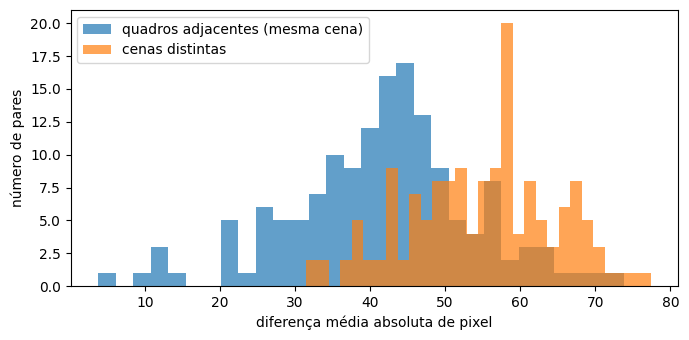

Mediana — quadros adjacentes: 42.24
Mediana — cenas distintas:    55.90


In [7]:
def miniatura(caminho):
    return np.asarray(Image.open(caminho).convert("L").resize((128, 102)), dtype=np.float32)


treino = catalogo[catalogo.split == "train"].sort_values(["cena", "indice"])
por_cena = {c: g.caminho.tolist() for c, g in treino.groupby("cena")}
rng = np.random.default_rng(SEMENTE)

dif_vizinhos, dif_cenas = [], []
for _ in range(150):
    c = rng.choice(list(por_cena))
    if len(por_cena[c]) < 2:
        continue
    i = rng.integers(0, len(por_cena[c]) - 1)
    dif_vizinhos.append(np.abs(miniatura(por_cena[c][i]) - miniatura(por_cena[c][i+1])).mean())
    c1, c2 = rng.choice(list(por_cena), 2, replace=False)
    dif_cenas.append(np.abs(miniatura(rng.choice(por_cena[c1])) - miniatura(rng.choice(por_cena[c2]))).mean())

plt.figure(figsize=(7, 3.5))
plt.hist(dif_vizinhos, bins=30, alpha=0.7, label="quadros adjacentes (mesma cena)")
plt.hist(dif_cenas, bins=30, alpha=0.7, label="cenas distintas")
plt.xlabel("diferença média absoluta de pixel")
plt.ylabel("número de pares")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mediana — quadros adjacentes: {np.median(dif_vizinhos):.2f}")
print(f"Mediana — cenas distintas:    {np.median(dif_cenas):.2f}")

## 6. A escala dos alvos

Agora a razão de treinar a 1280 pixels. A célula abaixo mede o **menor lado** de cada pessoa
anotada, em pixels da imagem original.

Ao ler a tabela, considere o que acontece dentro da rede. A YOLOv8 detecta objetos em três
escalas, com passos de 8, 16 e 32 pixels. Uma pessoa de 20 pixels de lado ocupa cerca de
2,5 células na escala mais fina — e praticamente desaparece nas outras duas. Se reduzíssemos a
entrada para 640 px, essa mesma pessoa passaria a ter 10 pixels e menos de 1,5 célula: sinal
insuficiente para uma detecção confiável.

Guarde a coluna `<20 px (%)`. Na seção 9 do **notebook 02** voltaremos a ela para explicar
*onde* o modelo erra.

,pessoas,p10,mediana,p90,<20 px (%)
train,18425.0,20.0,34.0,65.0,8.9
val,6546.0,23.0,37.0,64.0,4.0
test,1840.0,21.0,31.0,44.0,6.0


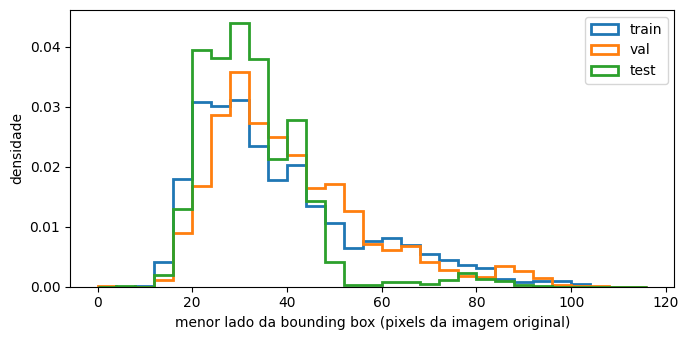

In [8]:
tabela_tamanho = pd.DataFrame({
    s: {
        "pessoas": len(v),
        "p10": np.percentile(v, 10),
        "mediana": np.median(v),
        "p90": np.percentile(v, 90),
        "<20 px (%)": 100 * np.mean(np.asarray(v) < 20),
    }
    for s, v in lados_por_split.items()
}).T.loc[["train", "val", "test"]]
display(tabela_tamanho.round(1))

plt.figure(figsize=(7, 3.5))
for s in ("train", "val", "test"):
    plt.hist(lados_por_split[s], bins=np.arange(0, 120, 4), density=True,
             histtype="step", linewidth=2, label=s)
plt.xlabel("menor lado da bounding box (pixels da imagem original)")
plt.ylabel("densidade")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Verificação visual

Números de integridade são necessários, mas não suficientes: eles confirmam que existem 26.811
caixas, não que essas caixas estão sobre as pessoas. A checagem final é olhar.

A célula abaixo desenha as anotações sobre seis imagens de treino. Confira se as caixas
envolvem as pessoas, e observe o quão pequenas elas são em relação ao quadro — é o mesmo dado
da seção 6, agora em forma visual.

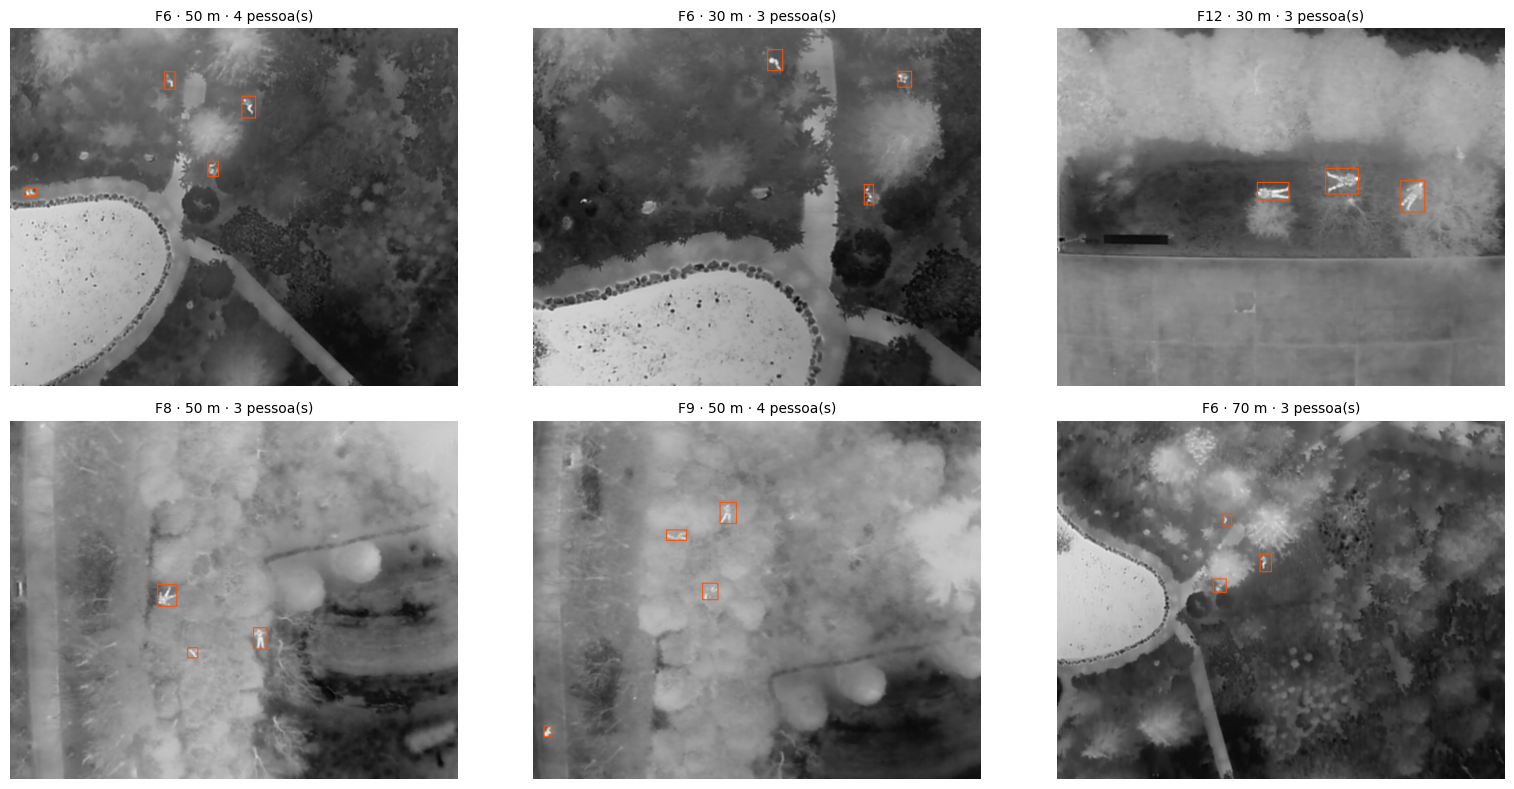

In [9]:
from PIL import ImageDraw

amostra = (catalogo[(catalogo.split == "train") & (catalogo.pessoas > 0)]
           .sample(6, random_state=SEMENTE).reset_index(drop=True))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (_, linha) in zip(axes.ravel(), amostra.iterrows()):
    img = Image.open(linha.caminho).convert("RGB")
    desenho = ImageDraw.Draw(img)
    caixas = ler_rotulos_yolo(POP_YOLO / "labels" / "train" / f"{linha.stem}.txt", LARGURA, ALTURA)
    for x1, y1, x2, y2 in caixas:
        desenho.rectangle([x1, y1, x2, y2], outline=(255, 80, 0), width=3)
    ax.imshow(img)
    ax.set_title(f"{linha.cena} · {linha.altitude:.0f} m · {len(caixas)} pessoa(s)", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Salvar o catálogo

O catálogo construído aqui é reutilizado pelo notebook `02_experimento_completo.ipynb`.
Salvamos em disco para que você não precise refazer esta preparação a cada execução.

**Você concluiu a preparação.** O que existe agora em disco:

- `data/pop_yolo/` — imagens e rótulos no formato que a Ultralytics espera
- `data/pop_yolo/pop.yaml` — a descrição do dataset
- `catalogo.csv` — o índice com cena, altitude e contagem de pessoas por imagem
- `ambiente_preparacao.json` — o registro do seu ambiente

Prossiga para o notebook **02_experimento_completo.ipynb**.

In [10]:
# Caminhos relativos permitem transportar a pasta de dados entre máquinas.
catalogo_salvo = catalogo.copy()
catalogo_salvo["caminho"] = catalogo_salvo["caminho"].map(lambda p: str(Path(p).relative_to(RAIZ)))
catalogo_salvo.to_csv(RAIZ / "catalogo.csv", index=False)
print("Catálogo salvo em:", RAIZ / "catalogo.csv")
print(f"{len(catalogo)} imagens · {int(catalogo.pessoas.sum())} pessoas anotadas")
print("\nPreparação concluída. Siga para 02_experimento_completo.ipynb")

Catálogo salvo em: /workspace/projeto-pop-es10-20260919/catalogo.csv
8768 imagens · 26811 pessoas anotadas

Preparação concluída. Siga para 02_experimento_completo.ipynb
